---
Title: "PA 6.1"
format:
    html:
        embed-resources: true
---

In [2]:
#!pip install palmerpenguins

In [3]:
import numpy as np
import pandas as pd
from sys import exit
from palmerpenguins import load_penguins
from plotnine import ggplot, aes, geom_point, geom_bar

0\. Complete the [**check-in** from Section 6.3.2](https://ds-ml-with-python.github.io/Course-Textbook/05-function_writing.html#nested-environments-and-scope): Write a custom function that does the following:

Limit the penguins dataset to a user-chosen species and/or island.
Makes a scatterplot of the penguin bill length and depth.
Try writing a version of this function using dynamic lookup, and a version where everything the function needs is passed in directly

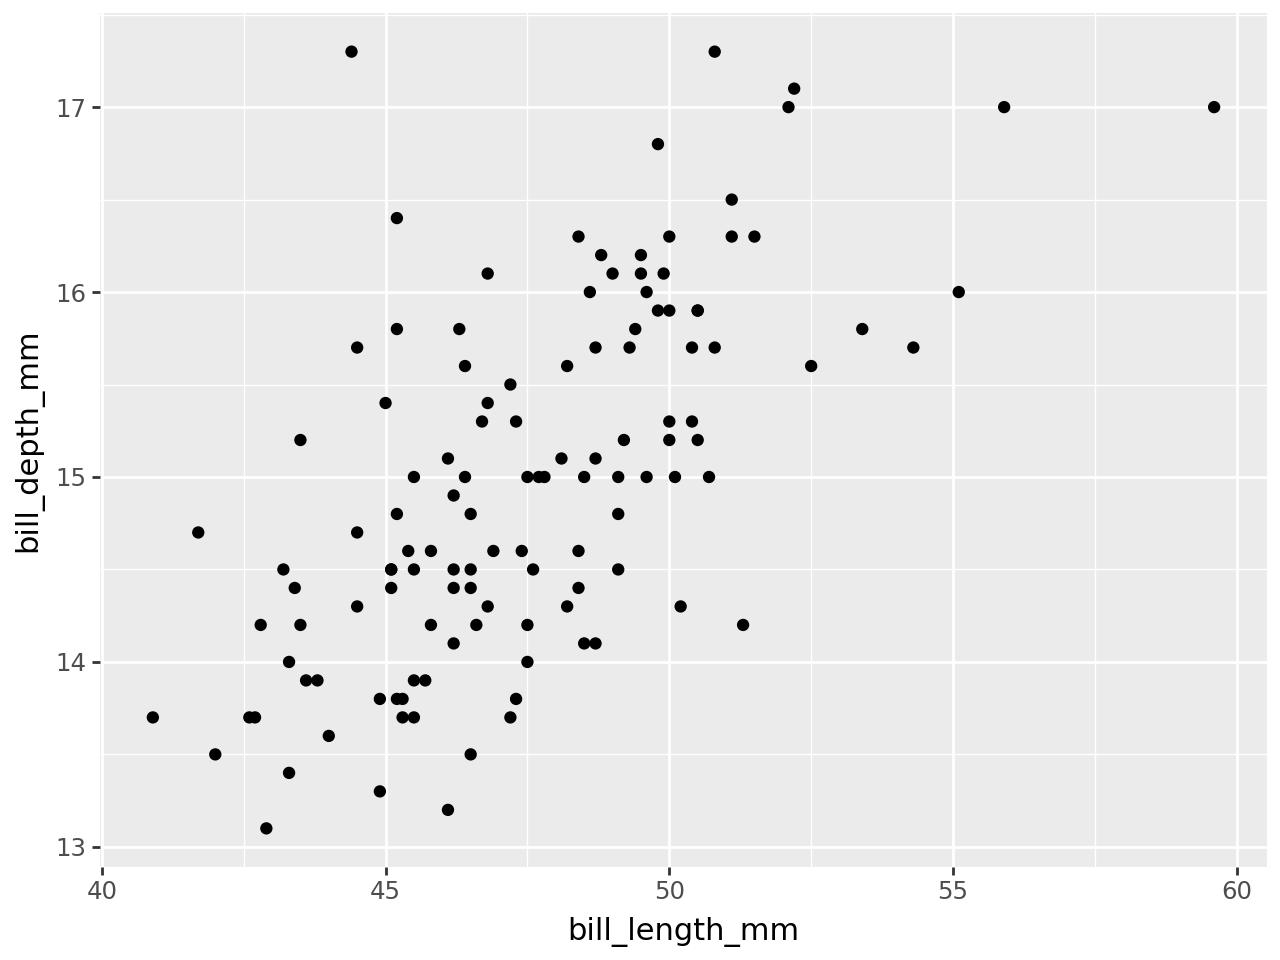

In [5]:
penguins = load_penguins()

# Version 1: dynamic lookup (uses the global penguins dataset)
def penguin_scatter_dynamic(species=None, island=None):
    data = penguins.copy()

    if species is not None:
        data = data[data["species"] == species]

    if island is not None:
        data = data[data["island"] == island]

    data = data.dropna(subset=["bill_length_mm", "bill_depth_mm"])

    return (
        ggplot(data, aes(x="bill_length_mm", y="bill_depth_mm"))
        + geom_point()
    )

penguin_scatter_dynamic(species="Adelie", island="Torgersen")

# Version 2: everything needed is passed into the function
def penguin_scatter(data, species=None, island=None):
    filtered_data = data.copy()

    if species is not None:
        filtered_data = filtered_data[filtered_data["species"] == species]

    if island is not None:
        filtered_data = filtered_data[filtered_data["island"] == island]

    filtered_data = filtered_data.dropna(
        subset=["bill_length_mm", "bill_depth_mm"]
    )

    return (
        ggplot(filtered_data, aes(x="bill_length_mm", y="bill_depth_mm"))
        + geom_point()
    )

penguin_scatter(penguins, species="Gentoo", island="Biscoe")

1. Fill in the necessary code to write a function called `times_seven()`. The function should take a single argument (`x`) and multiply the input by 7.
  + This function should check that the argument is numeric.
  + This function should also excitedly announce (print) *“I love sevens!”* if the argument to the function is a 7.

In [6]:
def times_seven(x):

    if not isinstance(x, (int, float)):
        exit("Error: x must be numeric.")

    if x == 7:
        print("I love sevens!")

    return x * 7

2. Write and run some *unit tests* for your `times_seven` function.  What happens if the input to the function is `[1, 3, 5, 7]`?

In [7]:
assert times_seven(1) == 7
assert times_seven(3) == 21
assert times_seven(5) == 35
assert times_seven(7) == 49

times_seven([1, 3, 5, 7])

I love sevens!


SystemExit: Error: x must be numeric.

/usr/local/lib/python3.13/dist-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.


3. Consider the following function:

In [10]:
def add_or_subtract(first_num, second_num = 2, type = "add"):

  if (type == "add"):
    res = first_num + second_num
  elif (type == "subtract"):
    res = first_num - second_num
  else:
    exit("Please choose `add` or `subtract` as the type.")

  return res

**Without running the code**, predict if the following will produce:

a. 1

b. -1

c. 30

d. An error defined by the function `add_or_subtract()`

e. An error defined in a different function, which is called inside the `add_or_subtract()` function

In [11]:
add_or_subtract(5, 6, type = "subtract") #b

add_or_subtract("orange") #d

add_or_subtract(5, 6, type = "multiply") #d

TypeError: can only concatenate str (not "int") to str

4. Consider the following code:

In [12]:
first_num  = 5
second_num = 3

result = 8

result = add_or_subtract(first_num, second_num = 4)

result_2 = add_or_subtract(first_num)

In [13]:
result

9

In [14]:
globals()

{'__name__': '__main__',
 '__doc__': 'Automatically created module for IPython interactive environment',
 '__package__': None,
 '__loader__': None,
 '__spec__': None,
 '__builtin__': <module 'builtins' (built-in)>,
 '__builtins__': <module 'builtins' (built-in)>,
 '_ih': ['',
  'import numpy as np\nimport pandas as pd\nfrom sys import exit\nfrom palmerpenguins import load_penguins\nfrom plotnine import ggplot, aes, geom_point, geom_bar',
  "get_ipython().system('pip install palmerpenguins')",
  'import numpy as np\nimport pandas as pd\nfrom sys import exit\nfrom palmerpenguins import load_penguins\nfrom plotnine import ggplot, aes, geom_point, geom_bar',
  'penguins = load_penguins()\n\n# Version 1: dynamic lookup (uses the global penguins dataset)\ndef penguin_scatter_dynamic(species=None, island=None):\n    data = penguins.copy()\n\n    if species is not None:\n        data = data[data["species"] == species]\n\n    if island is not None:\n        data = data[data["island"] == island]


In your Global Environment, what is the value of...

a. `first_num` #5

b. `second_num` #3

c. `result` #9

d. `result_2` #7